In [2]:
##primera celda, impors y rutas
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SCALED_PATH = DATA_DIR / "dataset_scaled.csv"
DATASET_ORIGINAL_PATH = DATA_DIR / "dataset.csv"
KMEANS_MODEL_PATH = MODELS_DIR / "kmeans.pkl"
CLUSTERED_DATASET_PATH = DATA_DIR / "dataset_clustered.csv"
INTERPRETATION_PATH = DOCS_DIR / "clustering_interpretation.md"

print("Project root:", PROJECT_ROOT)
print("Scaled dataset:", DATASET_SCALED_PATH.exists(), DATASET_SCALED_PATH)
print("Original dataset:", DATASET_ORIGINAL_PATH.exists(), DATASET_ORIGINAL_PATH)

Project root: /home/angel/projects/CNC_Project
Scaled dataset: True /home/angel/projects/CNC_Project/data/processed/dataset_scaled.csv
Original dataset: True /home/angel/projects/CNC_Project/data/processed/dataset.csv


In [3]:
##segunda celda, cargar dataset y revisar estructuras
df_scaled = pd.read_csv(DATASET_SCALED_PATH)

if DATASET_ORIGINAL_PATH.exists():
    df_original = pd.read_csv(DATASET_ORIGINAL_PATH)
else:
    df_original = df_scaled.copy()

print("Scaled shape:", df_scaled.shape)
print("Original shape:", df_original.shape)

display(df_scaled.head())
display(df_scaled.dtypes)

Scaled shape: (491, 29)
Original shape: (491, 29)


,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,dst2src_packets,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,bidirectional_syn_packets,bidirectional_ack_packets,...,iat_mean_ms_missing,iat_std_ms_missing,iat_cv_missing,rtt_estimate_ms_missing,tcp_window_min_missing,tcp_window_max_missing,tcp_window_mean_missing,tcp_window_var_missing,syn_ack_ratio_manual_missing,label
0,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
1,-0.869255,1.818521,0.794499,1.229215,0.818577,1.545013,0.818577,1.265758,0.931085,0.931085,...,-0.794499,-0.794499,-0.794499,-2.002549,-0.931085,-0.931085,-0.931085,-0.931085,-0.931085,normal
2,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
3,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
4,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan


protocol                          float64
bidirectional_duration_ms         float64
bidirectional_packets             float64
bidirectional_bytes               float64
dst2src_packets                   float64
src2dst_bytes                     float64
dst2src_bytes                     float64
bidirectional_mean_ps             float64
bidirectional_syn_packets         float64
bidirectional_ack_packets         float64
bidirectional_rst_packets         float64
bytes_asymmetry_ratio             float64
packets_asymmetry_ratio           float64
bidirectional_packets_per_ms      float64
bytes_per_packet                  float64
manual_packet_count               float64
iat_mean_ms                       float64
duration_zero_flag                float64
syn_ack_ratio_nfstream_missing    float64
iat_mean_ms_missing               float64
iat_std_ms_missing                float64
iat_cv_missing                    float64
rtt_estimate_ms_missing           float64
tcp_window_min_missing            

In [4]:
print("Columns:")
for col in df_scaled.columns:
    print("-", col)

print("\nMissing values:")
display(df_scaled.isna().sum().sort_values(ascending=False).head(20))

print("\nInfinite values:")
numeric_df = df_scaled.select_dtypes(include=[np.number])
print(np.isinf(numeric_df).sum().sort_values(ascending=False).head(20))

Columns:
- protocol
- bidirectional_duration_ms
- bidirectional_packets
- bidirectional_bytes
- dst2src_packets
- src2dst_bytes
- dst2src_bytes
- bidirectional_mean_ps
- bidirectional_syn_packets
- bidirectional_ack_packets
- bidirectional_rst_packets
- bytes_asymmetry_ratio
- packets_asymmetry_ratio
- bidirectional_packets_per_ms
- bytes_per_packet
- manual_packet_count
- iat_mean_ms
- duration_zero_flag
- syn_ack_ratio_nfstream_missing
- iat_mean_ms_missing
- iat_std_ms_missing
- iat_cv_missing
- rtt_estimate_ms_missing
- tcp_window_min_missing
- tcp_window_max_missing
- tcp_window_mean_missing
- tcp_window_var_missing
- syn_ack_ratio_manual_missing
- label

Missing values:


protocol                          0
bidirectional_duration_ms         0
bidirectional_packets             0
bidirectional_bytes               0
dst2src_packets                   0
src2dst_bytes                     0
dst2src_bytes                     0
bidirectional_mean_ps             0
bidirectional_syn_packets         0
bidirectional_ack_packets         0
bidirectional_rst_packets         0
bytes_asymmetry_ratio             0
packets_asymmetry_ratio           0
bidirectional_packets_per_ms      0
bytes_per_packet                  0
manual_packet_count               0
iat_mean_ms                       0
duration_zero_flag                0
syn_ack_ratio_nfstream_missing    0
iat_mean_ms_missing               0
dtype: int64


Infinite values:
protocol                          0
bidirectional_duration_ms         0
bidirectional_packets             0
bidirectional_bytes               0
dst2src_packets                   0
src2dst_bytes                     0
dst2src_bytes                     0
bidirectional_mean_ps             0
bidirectional_syn_packets         0
bidirectional_ack_packets         0
bidirectional_rst_packets         0
bytes_asymmetry_ratio             0
packets_asymmetry_ratio           0
bidirectional_packets_per_ms      0
bytes_per_packet                  0
manual_packet_count               0
iat_mean_ms                       0
duration_zero_flag                0
syn_ack_ratio_nfstream_missing    0
iat_mean_ms_missing               0
dtype: int64


In [5]:
##separar features y labels
LABEL_COL = "label"

if LABEL_COL not in df_scaled.columns:
    raise ValueError(f"No existe la columna '{LABEL_COL}' en dataset_scaled.csv")

non_feature_cols = {
    "label",
    "cluster",
    "flow_id",
    "id",
    "src_ip",
    "dst_ip",
    "application_name",
    "application_category_name",
    "requested_server_name",
    "client_fingerprint",
    "server_fingerprint",
    "user_agent",
    "content_type",
    "pcap_file",
    "pcap_path",
    "filename",
    "timestamp",
    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",
}

numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    col for col in numeric_cols
    if col not in non_feature_cols
]

X = df_scaled[feature_cols].copy()
y = df_scaled[LABEL_COL].copy()

print("Number of features used:", len(feature_cols))
print("Features used:")
for col in feature_cols:
    print("-", col)

print("\nLabel distribution:")
display(y.value_counts())
display(y.value_counts(normalize=True).round(4))

Number of features used: 28
Features used:
- protocol
- bidirectional_duration_ms
- bidirectional_packets
- bidirectional_bytes
- dst2src_packets
- src2dst_bytes
- dst2src_bytes
- bidirectional_mean_ps
- bidirectional_syn_packets
- bidirectional_ack_packets
- bidirectional_rst_packets
- bytes_asymmetry_ratio
- packets_asymmetry_ratio
- bidirectional_packets_per_ms
- bytes_per_packet
- manual_packet_count
- iat_mean_ms
- duration_zero_flag
- syn_ack_ratio_nfstream_missing
- iat_mean_ms_missing
- iat_std_ms_missing
- iat_cv_missing
- rtt_estimate_ms_missing
- tcp_window_min_missing
- tcp_window_max_missing
- tcp_window_mean_missing
- tcp_window_var_missing
- syn_ack_ratio_manual_missing

Label distribution:


label
udp_scan      129
normal        129
syn_scan      129
icmp_flood     61
port_sweep     43
Name: count, dtype: int64

label
udp_scan      0.2627
normal        0.2627
syn_scan      0.2627
icmp_flood    0.1242
port_sweep    0.0876
Name: proportion, dtype: float64

In [6]:
##sanity check antes de k-mean
print("Any NaN in X?", X.isna().any().any())
print("Any inf in X?", np.isinf(X.to_numpy()).any())

print("\nBasic descriptive stats of scaled features:")
display(X.describe().T[["mean", "std", "min", "max"]].round(4).head(30))

Any NaN in X? False
Any inf in X? False

Basic descriptive stats of scaled features:


,mean,std,min,max
protocol,0.0,1.001,-1.7171,7.9483
bidirectional_duration_ms,-0.0,1.001,-0.5499,1.8185
bidirectional_packets,-0.0,1.001,-1.2587,0.7945
bidirectional_bytes,-0.0,1.001,-1.3911,1.2292
dst2src_packets,0.0,1.001,-1.2216,0.8186
src2dst_bytes,0.0,1.001,-1.0786,1.5450
dst2src_bytes,-0.0,1.001,-1.2216,0.8186
bidirectional_mean_ps,-0.0,1.001,-1.2533,1.2658
bidirectional_syn_packets,0.0,1.001,-1.0740,0.9311
bidirectional_ack_packets,0.0,1.001,-1.0740,0.9311


In [7]:
##elbow method, k de 2 a 10
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    cluster_labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, cluster_labels))

results_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

display(results_k)

,k,inertia,silhouette
0,2,4673.211926,0.653593
1,3,2441.825610,0.714743
2,4,1194.022859,0.782829
3,5,734.540606,0.819050
4,6,590.845792,0.827015
5,7,512.042404,0.791001
6,8,438.518134,0.769961
7,9,369.032720,0.781589
8,10,307.802043,0.799134


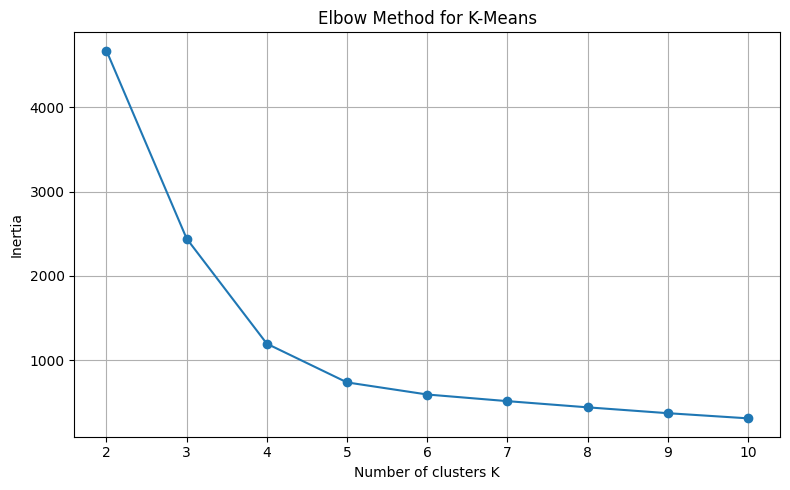

Saved: /home/angel/projects/CNC_Project/reports/figures/kmeans_elbow.png


In [8]:
##gráfica de elbow
plt.figure(figsize=(8, 5))
plt.plot(results_k["k"], results_k["inertia"], marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.tight_layout()

elbow_path = FIGURES_DIR / "kmeans_elbow.png"
plt.savefig(elbow_path, dpi=300)
plt.show()

print("Saved:", elbow_path)

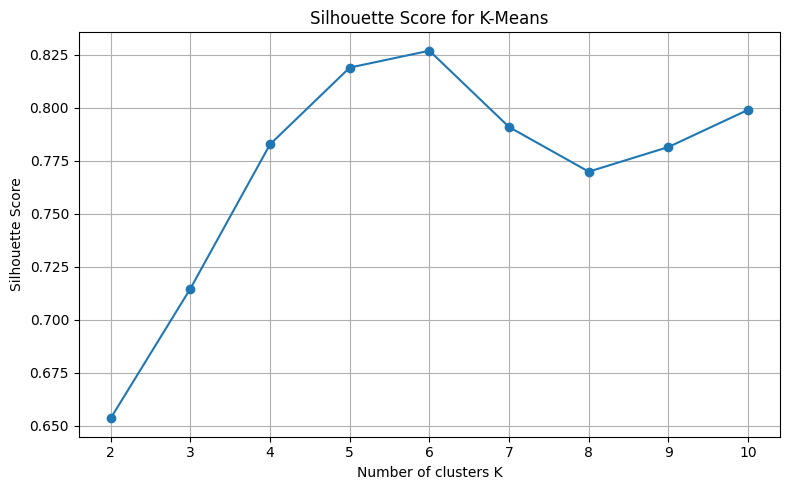

Saved: /home/angel/projects/CNC_Project/reports/figures/kmeans_silhouette.png


In [9]:
##gráfica de silhouette
plt.figure(figsize=(8, 5))
plt.plot(results_k["k"], results_k["silhouette"], marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.grid(True)
plt.tight_layout()

silhouette_path = FIGURES_DIR / "kmeans_silhouette.png"
plt.savefig(silhouette_path, dpi=300)
plt.show()

print("Saved:", silhouette_path)

In [10]:
##elegimos k óptimo
# Based on the Elbow Method and Silhouette Score:
# - The elbow curve shows a strong reduction until K=4, then the improvement becomes smaller.
# - The silhouette curve reaches its maximum at K=6.
# Therefore, we select K=6 as the final number of clusters.

OPTIMAL_K = 6

print("Selected OPTIMAL_K:", OPTIMAL_K)

Selected OPTIMAL_K: 6


## K selection

The Elbow Method shows a strong decrease in inertia from K=2 to K=4. After K=4, the curve starts to flatten, although there is still some improvement until K=5/K=6. The Silhouette Score reaches its maximum at K=6, which indicates that the natural geometric structure of the dataset is better represented by six clusters than by four.

Although the dataset contains five manually assigned traffic labels, K-Means is an unsupervised algorithm and does not use those labels during training. Therefore, it is acceptable that the optimal number of clusters differs from the number of classes. This suggests that some traffic classes may contain several internal behavioral patterns, such as short normal flows versus longer normal flows, or different scan patterns with similar duration and asymmetry but different TCP/UDP behavior.

For this reason, the final K-Means model is trained with K=6.

In [11]:
##entrenar k-means final con k=6
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=50
)

df_scaled["cluster"] = kmeans_final.fit_predict(X)
df_original["cluster"] = df_scaled["cluster"].values

print("Cluster distribution:")
display(df_scaled["cluster"].value_counts().sort_index())

joblib.dump(kmeans_final, KMEANS_MODEL_PATH)
print("K-Means model saved to:", KMEANS_MODEL_PATH)

Cluster distribution:


cluster
0    165
1    127
2     98
3     23
4     63
5     15
Name: count, dtype: int64

K-Means model saved to: /home/angel/projects/CNC_Project/models/kmeans.pkl


In [12]:
##PCA 2D para visualizar clusters
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_scaled["cluster"].astype(str),
    "label": y.astype(str)
})

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA explained variance ratio:
[0.70070185 0.18000608]
Total explained variance: 0.8807079331474306


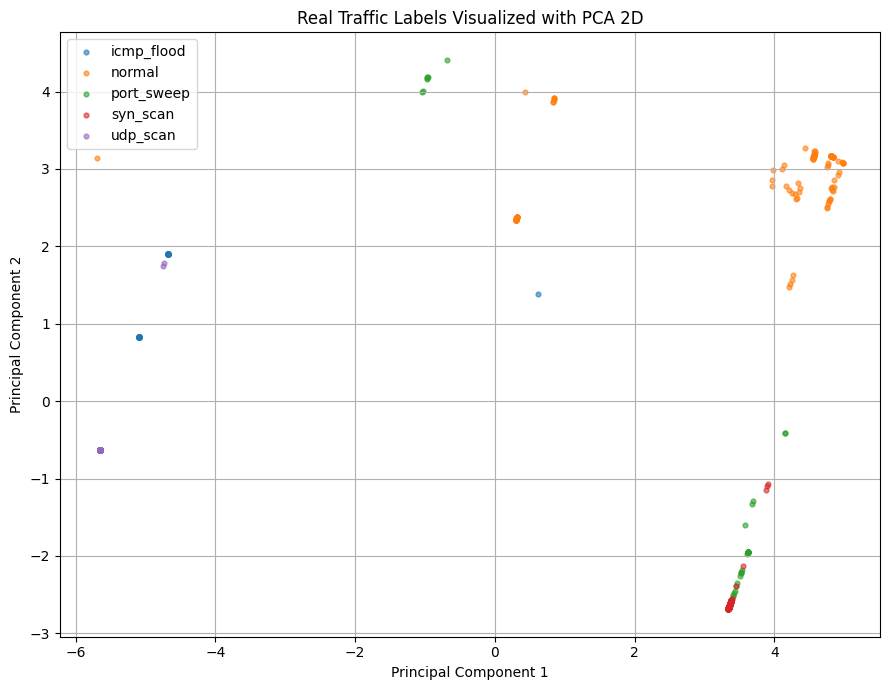

Saved: /home/angel/projects/CNC_Project/reports/figures/kmeans_pca_labels.png


In [13]:
##gráfico por label real
plt.figure(figsize=(9, 7))

for label_name in sorted(pca_df["label"].unique()):
    subset = pca_df[pca_df["label"] == label_name]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label_name,
        alpha=0.6,
        s=12
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Real Traffic Labels Visualized with PCA 2D")
plt.legend()
plt.grid(True)
plt.tight_layout()

pca_label_path = FIGURES_DIR / "kmeans_pca_labels.png"
plt.savefig(pca_label_path, dpi=300)
plt.show()

print("Saved:", pca_label_path)

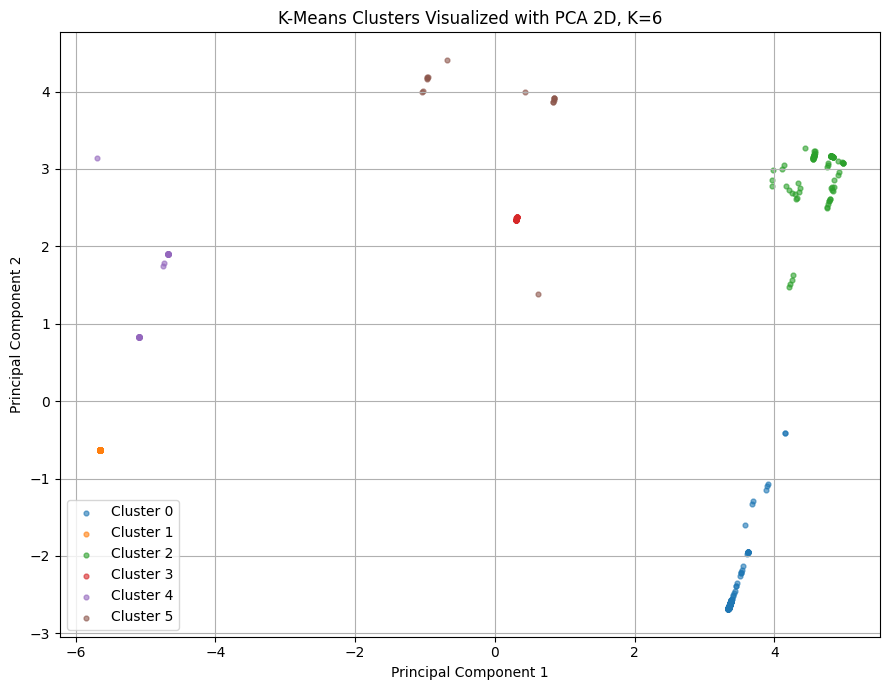

Saved: /home/angel/projects/CNC_Project/reports/figures/kmeans_pca_clusters_k6.png


In [14]:
## Gráfico PCA 2D coloreado por cluster

plt.figure(figsize=(9, 7))

for cluster_id in sorted(pca_df["cluster"].unique(), key=int):
    subset = pca_df[pca_df["cluster"] == cluster_id]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=12
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized with PCA 2D, K=6")
plt.legend()
plt.grid(True)
plt.tight_layout()

pca_cluster_path = FIGURES_DIR / "kmeans_pca_clusters_k6.png"
plt.savefig(pca_cluster_path, dpi=300)
plt.show()

print("Saved:", pca_cluster_path)

In [15]:
##analizar composición real de los cluster
cluster_label_counts = (
    df_scaled
    .groupby("cluster")[LABEL_COL]
    .value_counts()
    .rename("count")
    .reset_index()
)

cluster_label_proportions = (
    df_scaled
    .groupby("cluster")[LABEL_COL]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

composition_table = pd.crosstab(
    df_scaled["cluster"],
    df_scaled[LABEL_COL],
    normalize="index"
).round(4)

dominant_labels = (
    cluster_label_proportions
    .sort_values(["cluster", "proportion"], ascending=[True, False])
    .groupby("cluster")
    .head(1)
    .rename(columns={LABEL_COL: "dominant_label"})
)

print("Cluster-label counts:")
display(cluster_label_counts)

print("Cluster composition table:")
display(composition_table)

print("Dominant label per cluster:")
display(dominant_labels)

Cluster-label counts:


,cluster,label,count
0,0,syn_scan,129
1,0,port_sweep,36
2,1,udp_scan,127
3,2,normal,98
4,3,normal,23
5,4,icmp_flood,60
6,4,udp_scan,2
7,4,normal,1
8,5,normal,7
9,5,port_sweep,7


Cluster composition table:


label,icmp_flood,normal,port_sweep,syn_scan,udp_scan
cluster,,,,,
0,0.0000,0.0000,0.2182,0.7818,0.0000
1,0.0000,0.0000,0.0000,0.0000,1.0000
2,0.0000,1.0000,0.0000,0.0000,0.0000
3,0.0000,1.0000,0.0000,0.0000,0.0000
4,0.9524,0.0159,0.0000,0.0000,0.0317
5,0.0667,0.4667,0.4667,0.0000,0.0000


Dominant label per cluster:


,cluster,dominant_label,proportion
0,0,syn_scan,0.781818
2,1,udp_scan,1.000000
3,2,normal,1.000000
4,3,normal,1.000000
5,4,icmp_flood,0.952381
8,5,normal,0.466667


In [16]:
##analizar centroides escalados
centroids_scaled = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=feature_cols
)

display(centroids_scaled.round(3))

,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,dst2src_packets,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,bidirectional_syn_packets,bidirectional_ack_packets,...,syn_ack_ratio_nfstream_missing,iat_mean_ms_missing,iat_std_ms_missing,iat_cv_missing,rtt_estimate_ms_missing,tcp_window_min_missing,tcp_window_max_missing,tcp_window_mean_missing,tcp_window_var_missing,syn_ack_ratio_manual_missing
0,-0.869,-0.478,0.794,0.264,0.819,-0.442,0.819,-0.360,0.931,0.931,...,-0.931,-0.794,-0.794,-0.794,0.499,-0.931,-0.931,-0.931,-0.931,-0.931
1,0.996,-0.550,-1.259,-1.391,-1.222,-1.079,-1.222,-1.253,-1.074,-1.074,...,1.074,1.259,1.259,1.259,0.499,1.074,1.074,1.074,1.074,1.074
2,-0.869,1.722,0.794,1.229,0.819,1.545,0.819,1.254,0.931,0.931,...,-0.931,-0.794,-0.794,-0.794,-2.003,-0.931,-0.931,-0.931,-0.931,-0.931
3,0.996,-0.550,0.794,1.229,0.819,0.991,0.819,1.266,-1.074,-1.074,...,1.074,-0.794,-0.794,-0.794,0.499,1.074,1.074,1.074,1.074,1.074
4,1.106,-0.550,-1.259,-0.542,-1.222,0.259,-1.222,0.795,-1.074,-1.074,...,1.074,1.259,1.259,1.259,0.499,1.074,1.074,1.074,1.074,1.074
5,0.634,1.819,0.794,1.229,-0.134,1.293,-0.134,1.098,-1.074,-1.074,...,1.074,-0.794,-0.794,-0.794,0.499,1.074,1.074,1.074,1.074,1.074


In [17]:
##scar features más definidas por cluster
top_features_per_cluster = {}

for cluster_id in centroids_scaled.index:
    centroid = centroids_scaled.loc[cluster_id]
    top_features = (
        centroid
        .abs()
        .sort_values(ascending=False)
        .head(12)
        .index
        .tolist()
    )
    
    top_features_per_cluster[cluster_id] = (
        centroids_scaled
        .loc[cluster_id, top_features]
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

for cluster_id, features in top_features_per_cluster.items():
    print(f"\nCluster {cluster_id} - top defining scaled features:")
    display(features.round(3))


Cluster 0 - top defining scaled features:


bidirectional_rst_packets         1.406
packets_asymmetry_ratio          -0.947
bidirectional_ack_packets         0.931
bidirectional_syn_packets         0.931
syn_ack_ratio_manual_missing     -0.931
tcp_window_min_missing           -0.931
tcp_window_mean_missing          -0.931
tcp_window_max_missing           -0.931
syn_ack_ratio_nfstream_missing   -0.931
tcp_window_var_missing           -0.931
bytes_asymmetry_ratio            -0.872
protocol                         -0.869
Name: 0, dtype: float64


Cluster 1 - top defining scaled features:


bidirectional_bytes            -1.391
bidirectional_packets          -1.259
iat_mean_ms_missing             1.259
manual_packet_count            -1.259
iat_std_ms_missing              1.259
iat_cv_missing                  1.259
bidirectional_mean_ps          -1.253
bytes_per_packet               -1.253
dst2src_bytes                  -1.222
dst2src_packets                -1.222
packets_asymmetry_ratio         1.166
bidirectional_packets_per_ms   -1.158
Name: 1, dtype: float64


Cluster 2 - top defining scaled features:


...

iat_mean_ms                       1.756
bidirectional_mean_ps             1.266
bytes_per_packet                  1.266
bidirectional_bytes               1.229
tcp_window_min_missing            1.074
tcp_window_var_missing            1.074
tcp_window_mean_missing           1.074
tcp_window_max_missing            1.074
syn_ack_ratio_manual_missing      1.074
syn_ack_ratio_nfstream_missing    1.074
bidirectional_syn_packets        -1.074
bidirectional_ack_packets        -1.074
Name: 3, dtype: float64


Cluster 4 - top defining scaled features:


bidirectional_packets            -1.259
iat_cv_missing                    1.259
iat_mean_ms_missing               1.259
manual_packet_count              -1.259
iat_std_ms_missing                1.259
dst2src_packets                  -1.222
dst2src_bytes                    -1.222
packets_asymmetry_ratio           1.166
bidirectional_packets_per_ms     -1.158
bytes_asymmetry_ratio             1.147
protocol                          1.106
syn_ack_ratio_nfstream_missing    1.074
Name: 4, dtype: float64


Cluster 5 - top defining scaled features:


bidirectional_duration_ms         1.819
duration_zero_flag               -1.819
src2dst_bytes                     1.293
bidirectional_bytes               1.229
bytes_per_packet                  1.098
bidirectional_mean_ps             1.098
tcp_window_min_missing            1.074
tcp_window_var_missing            1.074
syn_ack_ratio_manual_missing      1.074
syn_ack_ratio_nfstream_missing    1.074
tcp_window_mean_missing           1.074
tcp_window_max_missing            1.074
Name: 5, dtype: float64

In [18]:
##perfil en unidades reales
candidate_key_features = [
    "bidirectional_duration_ms",
    "bidirectional_packets",
    "bidirectional_bytes",
    "bidirectional_mean_ps",
    "bidirectional_packets_per_ms",
    "iat_mean_ms",
    "iat_std_ms",
    "iat_cv",
    "rtt_ms",
    "tcp_window_mean",
    "tcp_window_var",
    "syn_ack_ratio_manual",
    "bidirectional_syn_packets",
    "bidirectional_ack_packets",
    "bidirectional_rst_packets",
    "bidirectional_fin_packets",
    "src2dst_bytes",
    "dst2src_bytes",
    "src2dst_packets",
    "dst2src_packets",
]

key_features = [col for col in candidate_key_features if col in df_original.columns]

print("Key features available for interpretation:")
for col in key_features:
    print("-", col)

cluster_profile_mean = df_original.groupby("cluster")[key_features].mean().round(4)
cluster_profile_median = df_original.groupby("cluster")[key_features].median().round(4)
cluster_profile_q25 = df_original.groupby("cluster")[key_features].quantile(0.25).round(4)
cluster_profile_q75 = df_original.groupby("cluster")[key_features].quantile(0.75).round(4)

print("\nCluster profile - mean:")
display(cluster_profile_mean)

print("\nCluster profile - median:")
display(cluster_profile_median)

print("\nCluster profile - Q25:")
display(cluster_profile_q25)

print("\nCluster profile - Q75:")
display(cluster_profile_q75)

Key features available for interpretation:
- bidirectional_duration_ms
- bidirectional_packets
- bidirectional_bytes
- bidirectional_mean_ps
- bidirectional_packets_per_ms
- iat_mean_ms
- bidirectional_syn_packets
- bidirectional_ack_packets
- bidirectional_rst_packets
- src2dst_bytes
- dst2src_bytes
- dst2src_packets

Cluster profile - mean:


,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,bidirectional_mean_ps,bidirectional_packets_per_ms,iat_mean_ms,bidirectional_syn_packets,bidirectional_ack_packets,bidirectional_rst_packets,src2dst_bytes,dst2src_bytes,dst2src_packets
cluster,,,,,,,,,,,,
0,0.0303,2.0,112.7636,56.0121,2.0000,0.0213,1.0,1.0,1.0,58.9818,54.0,1.0000
1,0.0000,1.0,42.0000,42.0000,1.0000,0.0129,0.0,0.0,0.0,42.0000,0.0,0.0000
2,0.9592,2.0,154.0000,81.3161,1.8139,0.0726,1.0,1.0,0.0,112.0000,54.0,1.0000
3,0.0000,2.0,154.0000,81.5000,2.0000,0.0877,0.0,0.0,0.0,97.2174,54.0,1.0000
4,0.0000,1.0,78.3016,74.1111,1.0000,0.0129,0.0,0.0,0.0,77.6984,0.0,0.0000
5,1.0000,2.0,154.0000,78.8667,1.8667,0.0641,0.0,0.0,0.0,105.2667,28.8,0.5333



Cluster profile - median:


,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,bidirectional_mean_ps,bidirectional_packets_per_ms,iat_mean_ms,bidirectional_syn_packets,bidirectional_ack_packets,bidirectional_rst_packets,src2dst_bytes,dst2src_bytes,dst2src_packets
cluster,,,,,,,,,,,,
0,0.0,2.0,112.0,56.0,2.0,0.0131,1.0,1.0,1.0,58.0,54.0,1.0
1,0.0,1.0,42.0,42.0,1.0,0.0129,0.0,0.0,0.0,42.0,0.0,0.0
2,1.0,2.0,154.0,81.5,2.0,0.0877,1.0,1.0,0.0,112.0,54.0,1.0
3,0.0,2.0,154.0,81.5,2.0,0.0877,0.0,0.0,0.0,96.0,54.0,1.0
4,0.0,1.0,82.0,81.5,1.0,0.0129,0.0,0.0,0.0,82.0,0.0,0.0
5,1.0,2.0,154.0,81.5,2.0,0.0877,0.0,0.0,0.0,112.0,54.0,1.0



Cluster profile - Q25:


,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,bidirectional_mean_ps,bidirectional_packets_per_ms,iat_mean_ms,bidirectional_syn_packets,bidirectional_ack_packets,bidirectional_rst_packets,src2dst_bytes,dst2src_bytes,dst2src_packets
cluster,,,,,,,,,,,,
0,0.0,2.0,112.0,56.0,2.0,0.0091,1.0,1.0,1.0,58.0,54.0,1.0
1,0.0,1.0,42.0,42.0,1.0,0.0129,0.0,0.0,0.0,42.0,0.0,0.0
2,1.0,2.0,154.0,81.5,2.0,0.0531,1.0,1.0,0.0,112.0,54.0,1.0
3,0.0,2.0,154.0,81.5,2.0,0.0877,0.0,0.0,0.0,96.0,54.0,1.0
4,0.0,1.0,66.0,66.0,1.0,0.0129,0.0,0.0,0.0,66.0,0.0,0.0
5,1.0,2.0,154.0,81.5,2.0,0.0476,0.0,0.0,0.0,98.5,0.0,0.0



Cluster profile - Q75:


,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,bidirectional_mean_ps,bidirectional_packets_per_ms,iat_mean_ms,bidirectional_syn_packets,bidirectional_ack_packets,bidirectional_rst_packets,src2dst_bytes,dst2src_bytes,dst2src_packets
cluster,,,,,,,,,,,,
0,0.0,2.0,112.0,56.0,2.0,0.0181,1.0,1.0,1.0,58.0,54.0,1.0
1,0.0,1.0,42.0,42.0,1.0,0.0129,0.0,0.0,0.0,42.0,0.0,0.0
2,1.0,2.0,154.0,81.5,2.0,0.0877,1.0,1.0,0.0,112.0,54.0,1.0
3,0.0,2.0,154.0,81.5,2.0,0.0877,0.0,0.0,0.0,99.0,54.0,1.0
4,0.0,1.0,88.0,81.5,1.0,0.0129,0.0,0.0,0.0,88.0,0.0,0.0
5,1.0,2.0,154.0,81.5,2.0,0.0877,0.0,0.0,0.0,112.0,54.0,1.0


In [19]:
##guardara dataset clusterizado
df_original.to_csv(CLUSTERED_DATASET_PATH, index=False)
print("Clustered dataset saved to:", CLUSTERED_DATASET_PATH)

Clustered dataset saved to: /home/angel/projects/CNC_Project/data/processed/dataset_clustered.csv


In [21]:
# Generate final clustering interpretation document

lines = []

lines.append("# K-Means Clustering Interpretation\n")
lines.append(f"Selected number of clusters: **K = {OPTIMAL_K}**.\n")

lines.append("## K selection\n")
lines.append(
    "K-Means was evaluated for K values from 2 to 10 using both the Elbow Method "
    "and the Silhouette Score. The Elbow curve shows a clear reduction in inertia "
    "from K=2 to K=4, after which the improvement becomes progressively smaller. "
    "However, the maximum Silhouette Score is obtained for K=6, indicating that "
    "the most compact and well-separated structure in the feature space contains "
    "six clusters.\n"
)

lines.append(
    "Although the dataset contains five manually assigned traffic labels, this "
    "discrepancy is expected in unsupervised learning. K-Means does not use the "
    "labels during training and only groups flows according to geometric similarity "
    "in the scaled feature space. Therefore, a single semantic traffic class can be "
    "split into multiple behavioral subgroups. For example, normal traffic can be "
    "separated into TCP-like and non-TCP/request-response patterns, while scanning "
    "traffic can be grouped according to protocol, duration, TCP flags and "
    "directionality. For this reason, K=6 was selected as the final clustering "
    "configuration.\n"
)

lines.append("## Elbow and Silhouette results\n")
lines.append(results_k.to_markdown(index=False))
lines.append("\n")

lines.append("## Cluster composition by real label\n")
lines.append(composition_table.to_markdown())
lines.append("\n")

lines.append("## Dominant label per cluster\n")
lines.append(dominant_labels.to_markdown(index=False))
lines.append("\n")

lines.append("## Cluster profiles in original feature units\n")
lines.append(cluster_profile_median.to_markdown())
lines.append("\n")

lines.append("## Technical interpretation\n")

lines.append("""
### Cluster 0 — TCP reconnaissance / SYN scan with reset

This cluster is mainly composed of `syn_scan` traffic, with a smaller proportion of `port_sweep`. It is characterized by extremely short flows, small packets, and the presence of SYN, ACK and RST flags. This behavior is coherent with TCP reconnaissance, especially half-open SYN scans, where the scanner sends SYN packets and aborts the connection using RST before completing a normal data exchange.

The presence of port sweep traffic in the same cluster is also reasonable, because port sweeps generate short low-volume probing flows with similar asymmetry and no meaningful payload transfer.

### Cluster 1 — UDP scan without response

This cluster is a pure `udp_scan` cluster. Its flows usually contain a single packet, no destination-to-source response and no TCP flags. This matches UDP scanning behavior: UDP has no handshake, and probes to closed or filtered ports may not generate a useful bidirectional flow.

### Cluster 2 — Normal short TCP traffic

This cluster contains only `normal` traffic. It is characterized by short bidirectional flows with SYN and ACK flags but no RST. Compared with the SYN scan cluster, the absence of reset behavior indicates that these flows are not aborted in the same way as half-open scans.

### Cluster 3 — Normal non-TCP / short request-response traffic

This cluster also contains only `normal` traffic, but unlike Cluster 2, it has no TCP flags. This suggests normal non-TCP or request-response traffic. K-Means separates it from normal TCP traffic because the feature geometry is different, even though both groups share the same semantic label.

### Cluster 4 — ICMP flood / one-way control traffic

This cluster is mainly composed of `icmp_flood` traffic. It is characterized by one-packet flows, zero duration, no destination-to-source bytes and no TCP flags. This is coherent with ICMP flood behavior, where packets are generated rapidly without TCP state or handshake.

### Cluster 5 — Ambiguous short bidirectional flows

This is the least pure cluster. It contains both `normal` and `port_sweep` flows. The common pattern is short bidirectional traffic without TCP flags. This indicates that some port sweep flows can resemble normal request-response traffic when only isolated per-flow L3/L4 features are used.

A possible improvement would be to add temporal aggregation features such as the number of unique destination ports contacted per source IP, number of destination hosts per time window, or scan rate. These features would represent scanning behavior more directly than per-flow statistics alone.
""")

INTERPRETATION_PATH.write_text("\n".join(lines), encoding="utf-8")

print("Interpretation document saved to:", INTERPRETATION_PATH)

K-Means was evaluated for K values from 2 to 10 using both the Elbow Method and the Silhouette Score. The inertia curve shows a clear reduction from K=2 to K=4, after which the improvement becomes progressively smaller. However, the maximum Silhouette Score is obtained for K=6, indicating that the most compact and well-separated structure in the feature space contains six clusters.

The Silhouette Score reaches its maximum at K=6, which indicates that the natural geometric structure of the dataset is better represented by six clusters than by a lower number of clusters, this discrepancy is expected in unsupervised learning. K-Means does not use the labels during training and only groups flows according to geometric similarity in the scaled feature space. Therefore, a single traffic class can be split into multiple behavioral subgroups. For example, normal traffic may include both short HTTP/DNS-like flows and longer FTP-like flows, while scanning traffic may be divided according to protocol, duration, TCP flags and asymmetry. For this reason, K=6 was selected as the final clustering configuration.